# Pipeline de Viagens a Serviço — Camada Gold

Análise exploratória sobre a base de Viagens a Serviço do Portal da Transparência (Governo Federal), consumindo dados já limpos e tipados da camada Silver.

**Fonte:** [Portal da Transparência — Viagens a Serviço](https://portaldatransparencia.gov.br)
**Período:** 2025 (recorte semestral)

## Setup

- Importação das bibliotecas.
- Conexão com o banco MySQL, usando as funções prontas em `banco.py`.
- `consultar(sql)`: roda um comando SQL e devolve o resultado como tabela do pandas.
- `reais(valor)`: formata número em reais para exibição.

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import textwrap

import banco

conexao = banco.conectar()

def consultar(sql):
    return pd.read_sql(sql, conexao)

def reais(valor):
    texto = f'{valor:,.2f}'
    return 'R$ ' + texto.replace(',', 'X').replace('.', ',').replace('X', '.')

def formata_milhar(x, _=None):
    return f'{x:,.0f}'.replace(',', '.')

## 1. Os 5 órgãos com maior custo total

Consulta direta sobre `silver_viagem`, somando `valor_total` por `nome_orgao_superior`.

**Gráfico:** barras horizontais, escolhidas porque os nomes dos ministérios são longos. Eixo X em milhões para melhor visualização, com valor exato ao lado de cada barra.

In [93]:
sql_top_orgaos = """
    SELECT  nome_orgao_superior     AS  nome_orgao, 
            SUM(valor_total)        AS  custo_total
    FROM    silver_viagem
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5; 
"""

df_top_orgaos = consultar(sql_top_orgaos)
df_top_orgaos_exibicao = df_top_orgaos.copy()
df_top_orgaos_exibicao['custo_total'] = df_top_orgaos_exibicao['custo_total'].apply(reais)
df_top_orgaos_exibicao

C:\Users\mathe\AppData\Local\Temp\ipykernel_8372\3312108901.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao,custo_total
0,Ministério da Justiça e Segurança Pública,"R$ 486.933.121,65"
1,Ministério da Defesa,"R$ 156.070.304,49"
2,Ministério da Educação,"R$ 111.291.349,34"
3,Ministério do Meio Ambiente e Mudança do Clima,"R$ 49.697.710,16"
4,Ministério da Previdência Social,"R$ 40.417.309,06"


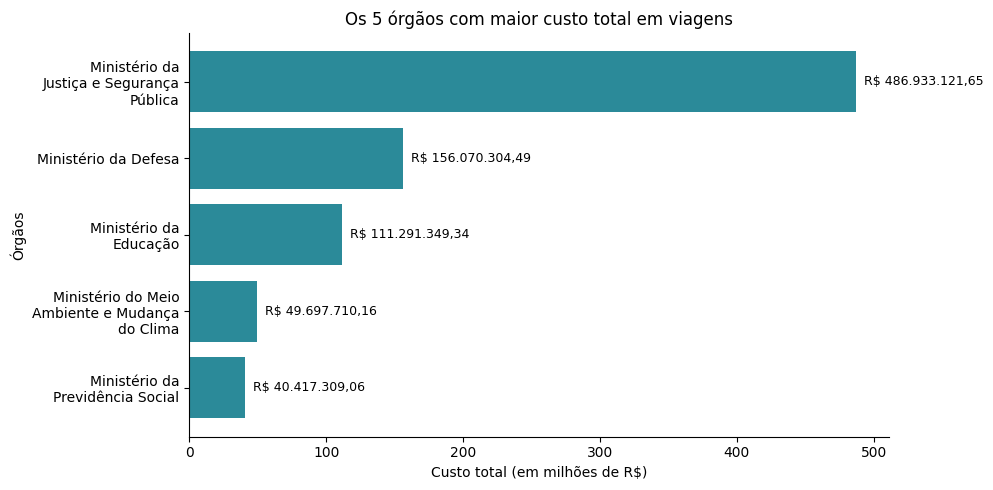

In [94]:
nomes_quebrados = [textwrap.fill(nome, 20) for nome in df_top_orgaos['nome_orgao']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(nomes_quebrados, df_top_orgaos['custo_total'], color="#2b8a99")
ax.invert_yaxis()
ax.set_title('Os 5 órgãos com maior custo total em viagens')

def em_milhoes(x, _):
    return f'{x/1_000_000:,.0f}'.replace(',', '.')

ax.xaxis.set_major_formatter(FuncFormatter(em_milhoes))
ax.set_xlabel('Custo total (em milhões de R$)')
ax.set_ylabel('Órgãos')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, valor in enumerate(df_top_orgaos['custo_total']):
    ax.text(valor, i, '  ' + reais(valor), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Os 3 destinos com maior custo médio por viagem

Esta pergunta passou por duas correções antes da versão final:

1. **Primeira tentativa:** agrupar pelo campo `destinos` de `silver_viagem` (texto livre, concatenando múltiplos locais numa única viagem). Resultado: destinos com apenas 1 ocorrência distorciam a média, e strings como "Brasília, Brasília, Brasília..." não representavam destinos reais e interpretáveis.
2. **Segunda tentativa:** usar `silver_trecho` (dado já estruturado, uma linha por destino), com `HAVING COUNT(*) >= 30` para volume mínimo de amostra. Ainda assim, viagens com múltiplos trechos "herdavam" o custo total inteiro em cada destino visitado, inflando a média de destinos que apareciam em viagens complexas.
3. **Versão final:** considerar apenas viagens de trecho único (`HAVING COUNT(*) = 1` na subconsulta), garantindo que o `valor_total` de cada viagem reflita genuinamente o custo daquele destino específico, sem diluição por outros trechos.

**Gráfico:** barras horizontais, com valores em reais ao lado de cada barra.

In [95]:
sql_top_destinos = """
    SELECT
        t.destino_uf,
        t.destino_cidade,
        AVG(v.valor_total) AS custo_medio,
        COUNT(*) AS qtd_viagens
    FROM silver_trecho t
    JOIN silver_viagem v ON t.id_viagem = v.id_viagem
    WHERE t.id_viagem IN (
        SELECT id_viagem
        FROM silver_trecho
        GROUP BY id_viagem
        HAVING COUNT(*) = 1
    )
    GROUP BY t.destino_uf, t.destino_cidade
    HAVING COUNT(*) >= 30
    ORDER BY custo_medio DESC
    LIMIT 3;
"""

df_top_destinos = consultar(sql_top_destinos)

df_top_destinos_exibicao = df_top_destinos.copy()
df_top_destinos_exibicao['custo_medio'] = df_top_destinos_exibicao['custo_medio'].apply(reais)
df_top_destinos_exibicao

C:\Users\mathe\AppData\Local\Temp\ipykernel_8372\3312108901.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino_uf,destino_cidade,custo_medio,qtd_viagens
0,,Washington,"R$ 5.137,92",60
1,Distrito Federal,Brasília,"R$ 3.167,84",797
2,Paraná,Londrina,"R$ 3.056,90",54


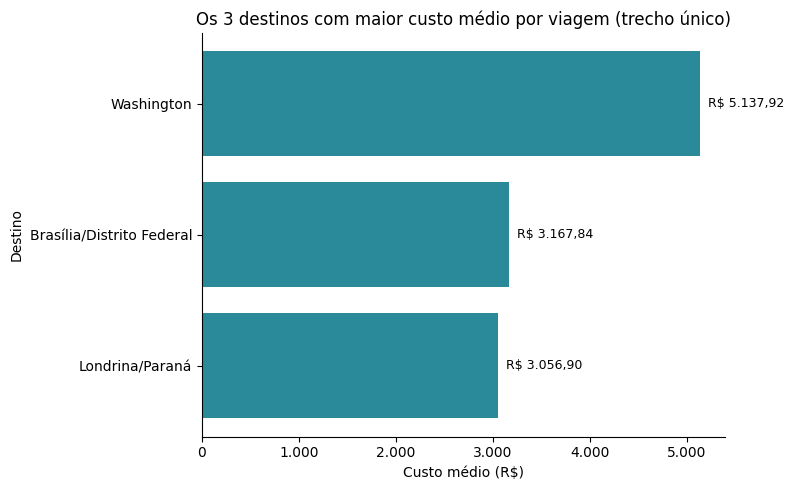

In [96]:
rotulos = [f"{row['destino_cidade']}/{row['destino_uf']}" if row['destino_uf'] else row['destino_cidade']
           for _, row in df_top_destinos.iterrows()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rotulos, df_top_destinos['custo_medio'], color='#2b8a99')
ax.invert_yaxis()
ax.set_title('Os 3 destinos com maior custo médio por viagem (trecho único)')
ax.set_xlabel('Custo médio (R$)')
ax.set_ylabel('Destino')
ax.xaxis.set_major_formatter(FuncFormatter(formata_milhar))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, valor in enumerate(df_top_destinos['custo_medio']):
    ax.text(valor, i, '  ' + reais(valor), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 3. A viagem de maior duração e seu custo total

Consulta ordenando `silver_viagem` por `duracao_dias`, pegando o registro do topo.

**Gráfico:** como o resultado é um único registro, uma barra isolada não teria contexto. Optei por  a viagem recordista contra a média geral de duração, mostrando visualmente com foge do padrão.

In [97]:
sql_maior_viagem = """
    SELECT  id_viagem,
            nome_viajante,
            nome_orgao_superior,
            destinos,
            data_inicio,
            data_fim,
            duracao_dias,
            valor_total
    FROM silver_viagem
    ORDER BY duracao_dias DESC
    LIMIT 1;
"""
df_maior_viagem = consultar(sql_maior_viagem)
df_maior_viagem


C:\Users\mathe\AppData\Local\Temp\ipykernel_8372\3312108901.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,id_viagem,nome_viajante,nome_orgao_superior,destinos,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,Mogi Mirim/SP,2025-01-13,2026-01-31,383,0.0


C:\Users\mathe\AppData\Local\Temp\ipykernel_8372\3312108901.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


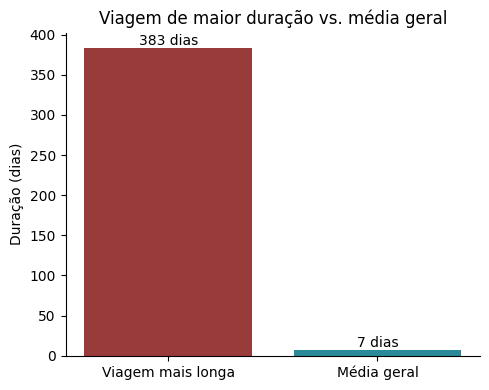

In [98]:
sql_media_duracao = """
    SELECT AVG(duracao_dias) AS media_duracao
    FROM silver_viagem
    WHERE duracao_dias IS NOT NULL;
"""
df_media = consultar(sql_media_duracao)
media_duracao = df_media['media_duracao'][0]

fig, ax = plt.subplots(figsize=(5, 4))
categorias = ['Viagem mais longa', 'Média geral']
valores = [df_maior_viagem['duracao_dias'][0], media_duracao]

ax.bar(categorias, valores, color=["#9a3b3b", "#2b8a99"])
ax.set_title('Viagem de maior duração vs. média geral')
ax.set_ylabel('Duração (dias)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, valor in enumerate(valores):
    ax.text(i, valor, f'{valor:.0f} dias', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Camada Gold agregada

Criacao da camada Gold que junta `silver_pagamento` e `silver_viagem` via JOIN, agrupando por órgão e tipo de pagamento (`GROUP BY`). Essa agregação é criada tanto **tabela** (`gold_pagamento_por_orgao`) quanto **VIEW** (`vw_gold_pagamento_por_orgao`).

In [99]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_pagamento_por_orgao")

sql_gold_pagamento = """
    CREATE TABLE    gold_pagamento_por_orgao AS
    SELECT  v.nome_orgao_superior,
            p.tipo_pagamento,
            COUNT(*)        AS qtd_pagamentos,
            SUM(p.valor)    AS valor_total,
            AVG(p.valor)    AS valor_medio
    FROM silver_pagamento p
    JOIN silver_viagem v ON p.id_viagem = v.id_viagem
    GROUP BY v.nome_orgao_superior, p.tipo_pagamento;
"""
banco.executar(conexao, sql_gold_pagamento)

sql_gold_view = """
    CREATE OR REPLACE VIEW vw_gold_pagamento_por_orgao AS
    SELECT  v.nome_orgao_superior,
            p.tipo_pagamento,
            COUNT(*)        AS qtd_pagamentos,
            SUM(p.valor)    AS valor_total,
            AVG(p.valor)    AS valor_medio
    FROM silver_pagamento p
    JOIN silver_viagem v ON p.id_viagem = v.id_viagem
    GROUP BY v.nome_orgao_superior, p.tipo_pagamento;
"""
banco.executar(conexao, sql_gold_view)

print("Gold e VIEW criadas com sucesso!")

Gold e VIEW criadas com sucesso!


## 4. Tipo de pagamento com maior valor médio

Consulta feita sobre a camada Gold (`gold_pagamento_por_orgao`), que junta `silver_pagamento` e `silver_viagem` por órgão e tipo de pagamento. Como a Gold já está agregada em duas dimensões, a média geral por tipo de pagamento é recalculada a partir dos totais (`SUM(valor_total) / SUM(qtd_pagamentos)`), evitando tirar uma "média das médias".

**Gráfico:** barras verticais, já que os nomes dos tipos de pagamento são curtos.

In [100]:
sql_maior_forma_pagamento = """
    SELECT  tipo_pagamento,
            SUM(valor_total)                      AS valor_total,
            SUM(qtd_pagamentos)                   AS qtd_pagamentos,
            SUM(valor_total) / SUM(qtd_pagamentos) AS valor_medio
    FROM gold_pagamento_por_orgao
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC;
"""

df_maior_forma_pagamento = consultar(sql_maior_forma_pagamento)

df_maior_forma_pagamento_exibicao = df_maior_forma_pagamento.copy()
df_maior_forma_pagamento_exibicao['valor_medio'] = df_maior_forma_pagamento_exibicao['valor_medio'].apply(reais)
df_maior_forma_pagamento_exibicao

C:\Users\mathe\AppData\Local\Temp\ipykernel_8372\3312108901.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,tipo_pagamento,valor_total,qtd_pagamentos,valor_medio
0,DIÁRIAS,8.343526e+08,401463.0,"R$ 2.078,28"
1,PASSAGEM,3.549789e+08,188985.0,"R$ 1.878,34"
2,Serviço correlato: seguro,2.190137e+06,4894.0,"R$ 447,51"
3,RESTITUIÇÃO,2.843762e+06,11574.0,"R$ 245,70"


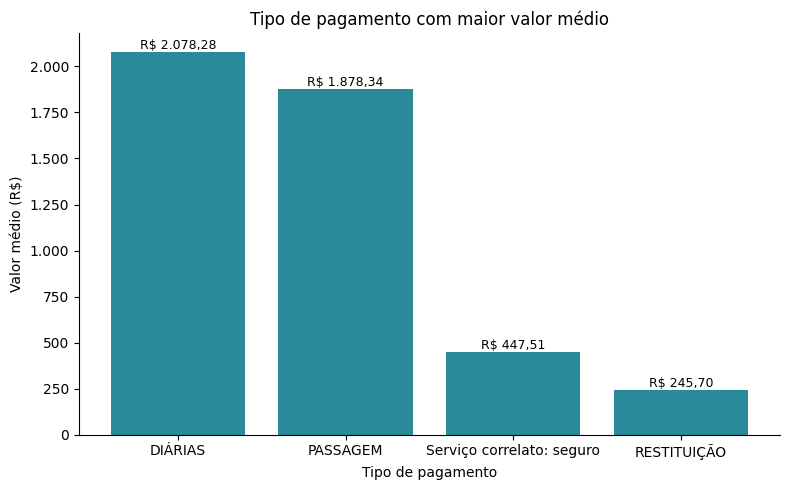

In [101]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_maior_forma_pagamento['tipo_pagamento'], df_maior_forma_pagamento['valor_medio'], color='#2b8a99')
ax.set_title('Tipo de pagamento com maior valor médio')
ax.set_xlabel('Tipo de pagamento')
ax.set_ylabel('Valor médio (R$)')
ax.yaxis.set_major_formatter(FuncFormatter(formata_milhar))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, valor in enumerate(df_maior_forma_pagamento['valor_medio']):
    ax.text(i, valor, reais(valor), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Meio de transporte mais usado nos trechos

Consulta com JOIN entre `silver_trecho` e `silver_viagem`, agrupando por `meio_transporte`.

**Gráfico:** barras horizontais, já que alguns nomes de meio de transporte podem ser mais longos.

In [102]:
sql_transporte = """
    SELECT  t.meio_transporte,
            COUNT(*)    AS qtd_trechos
    FROM silver_trecho t
    JOIN silver_viagem v ON t.id_viagem = v.id_viagem
    GROUP BY t.meio_transporte
    ORDER BY qtd_trechos DESC;
"""

df_transporte = consultar(sql_transporte)
df_transporte_exibicao = df_transporte.copy()
df_transporte_exibicao['qtd_trechos'] = df_transporte_exibicao['qtd_trechos'].apply(lambda x: f'{x:,.0f}'.replace(',', '.'))
df_transporte_exibicao

C:\Users\mathe\AppData\Local\Temp\ipykernel_8372\3312108901.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,meio_transporte,qtd_trechos
0,Veículo Oficial,386.424
1,Aéreo,232.666
2,Rodoviário,64.970
3,Veículo Próprio,42.846
4,Inválido,26.659
5,Fluvial,8.429
6,Ferroviário,874
7,Marítimo,481


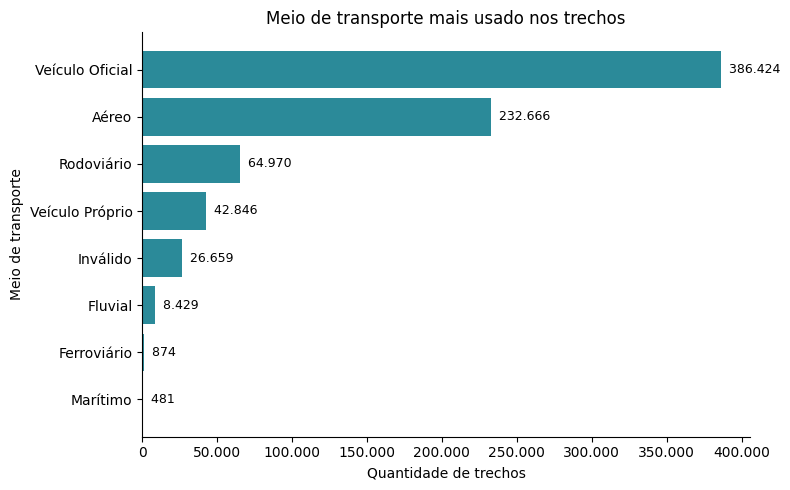

In [103]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_transporte['meio_transporte'], df_transporte['qtd_trechos'], color='#2b8a99')
ax.invert_yaxis()
ax.set_title('Meio de transporte mais usado nos trechos')
ax.set_xlabel('Quantidade de trechos')
ax.set_ylabel('Meio de transporte')
ax.xaxis.set_major_formatter(FuncFormatter(formata_milhar))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, valor in enumerate(df_transporte['qtd_trechos']):
    ax.text(valor, i, '  ' + formata_milhar(valor, None), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. UF de destino que aparece em mais trechos

Consulta com JOIN entre `silver_trecho` e `silver_viagem`, agrupando por `destino_uf`, com as 5 UFs mais frequentes.

**Gráfico:** barras horizontais, com a UF líder destacada em uma cor diferente das demais — reforça visualmente a resposta da pergunta, mantendo o contexto do ranking completo (2º ao 5º lugar).

In [104]:
sql_uf_destino = """
    SELECT
        t.destino_uf,
        COUNT(*) AS qtd_trechos
    FROM silver_trecho t
    JOIN silver_viagem v ON t.id_viagem = v.id_viagem
    GROUP BY t.destino_uf
    ORDER BY qtd_trechos DESC
    LIMIT 5;
"""

df_uf_destino = consultar(sql_uf_destino)

df_uf_destino_exibicao = df_uf_destino.copy()
df_uf_destino_exibicao['qtd_trechos'] = df_uf_destino_exibicao['qtd_trechos'].apply(lambda x: f'{x:,.0f}'.replace(',', '.'))
df_uf_destino_exibicao

C:\Users\mathe\AppData\Local\Temp\ipykernel_8372\3312108901.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino_uf,qtd_trechos
0,São Paulo,82.722
1,Distrito Federal,79.962
2,Minas Gerais,50.965
3,Rio de Janeiro,44.197
4,Paraná,42.603


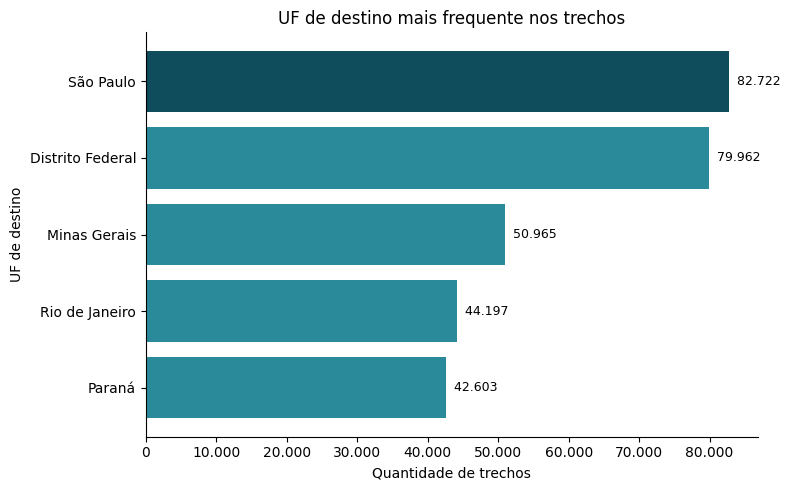

In [105]:
cor_base = '#2b8a99'
cor_destaque = '#0f4c5c'
cores = [cor_destaque] + [cor_base] * (len(df_uf_destino) - 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_uf_destino['destino_uf'], df_uf_destino['qtd_trechos'], color=cores)
ax.invert_yaxis()
ax.set_title('UF de destino mais frequente nos trechos')
ax.set_xlabel('Quantidade de trechos')
ax.set_ylabel('UF de destino')
ax.xaxis.set_major_formatter(FuncFormatter(formata_milhar))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, valor in enumerate(df_uf_destino['qtd_trechos']):
    ax.text(valor, i, '  ' + formata_milhar(valor, None), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Órgão que pagou mais no total

Consulta sobre a camada Gold (`gold_pagamento_por_orgao`), somando os valores por `nome_orgao_superior` usando a estrutura já agregada.

**Gráfico:** como a pergunta pede um único órgão (não um ranking), uma barra isolada não teria contexto suficiente. Optei por um gráfico de pizza comparando o órgão líder contra a soma de todos os demais órgãos, com percentual, para destacar o peso relativo do órgão vencedor dentro do total geral pago em viagens.

In [ ]:
sql_orgao_mais_pagou = """
    SELECT  nome_orgao_superior,
            SUM(valor_total)    AS valor_total
    FROM gold_pagamento_por_orgao
    GROUP BY nome_orgao_superior
    ORDER BY valor_total DESC
    LIMIT 1;
"""

df_orgao_mais_pagou = consultar(sql_orgao_mais_pagou)
df_orgao_mais_pagou_exibicao = df_orgao_mais_pagou.copy()
df_orgao_mais_pagou_exibicao['valor_total'] = df_orgao_mais_pagou_exibicao['valor_total'].apply(reais)
df_orgao_mais_pagou_exibicao

C:\Users\mathe\AppData\Local\Temp\ipykernel_8372\3312108901.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_superior,valor_total
0,Ministério da Justiça e Segurança Pública,"R$ 488.831.110,61"


C:\Users\mathe\AppData\Local\Temp\ipykernel_8372\3312108901.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


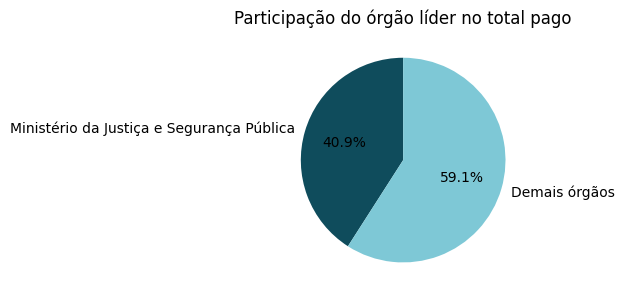

In [107]:
sql_total_geral = """
    SELECT SUM(valor) AS total_geral
    FROM silver_pagamento;
"""
df_total_geral = consultar(sql_total_geral)
total_geral = df_total_geral['total_geral'][0]

valor_lider = df_orgao_mais_pagou['valor_total'][0]
valor_resto = total_geral - valor_lider
nome_lider = df_orgao_mais_pagou['nome_orgao_superior'][0]

fig, ax = plt.subplots(figsize=(6, 6))

valores = [valor_lider, valor_resto]
labels = [nome_lider, 'Demais órgãos']
cores = ['#0f4c5c', '#7ec8d6']

ax.pie(
    valores,
    labels=labels,
    autopct='%1.1f%%',
    colors=cores,
    startangle=90,
    textprops={'fontsize': 10}
)
ax.set_title('Participação do órgão líder no total pago')
plt.tight_layout()
plt.show()

## Conclusões

A análise mostrou um padrão que faz sentido: órgãos com mais estrutura operacional, como Justiça e Defesa, concentram a maior parte dos gastos com viagens. Só o Ministério da Justiça e Segurança Pública responde por 40,9% de todo o valor pago no período.

Também encontramos algumas limitações no dado bruto, como uma viagem de 383 dias sem nenhum valor registrado, ou a categoria "Inválido" no meio de transporte. 

Mais detalhes estão no `README.md` do repositório.

In [108]:
conexao.close()
print("Conexão encerrada.")

Conexão encerrada.
